# Business Analysis

This notebook explores key business questions related to product performance, customer engagement, pricing strategy and category performance.

The objective is to transform data into actionable insights that support business decision-making.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
products = pd.read_csv("../data/products_engineered.csv")

## Executive Overview

This section provides a high-level overview of the marketplace before exploring specific business questions.

In [3]:
products.shape

(8493, 32)

In [4]:
products["brand_name"].nunique()

304

In [5]:
products["primary_category"].nunique()

9

In [6]:
products["price_usd"].mean()

np.float64(51.65355233721888)

In [7]:
products["rating"].mean()

np.float64(4.194444978697504)

In [8]:
products["loves_count"].sum()

np.int64(247814941)

In [9]:
products["reviews"].sum()

np.float64(3684939.0)

In [10]:
products["primary_category"].value_counts()

primary_category
Skincare           2420
Makeup             2368
Hair               1464
Fragrance          1432
Bath & Body         405
Mini Size           288
Men                  60
Tools & Brushes      52
Gifts                 4
Name: count, dtype: int64

In [11]:
products["brand_name"].value_counts().head(10)

brand_name
SEPHORA COLLECTION         352
CLINIQUE                   179
Dior                       136
tarte                      131
NEST New York              115
Bumble and bumble          110
Kérastase                  108
TOM FORD                   100
Charlotte Tilbury           99
Anastasia Beverly Hills     95
Name: count, dtype: int64

In [12]:
products["price_segment"].value_counts()

price_segment
Mid-range    4724
Premium      1633
Budget       1205
Luxury        931
Name: count, dtype: int64

In [13]:
brand_summary = (
    products
    .groupby("brand_name")
    .agg(
        products=("product_id","count"),
        total_loves=("loves_count","sum"),
        avg_rating=("rating","mean"),
        total_reviews=("reviews","sum"),
        avg_price=("price_usd","mean")
    )
    .sort_values("total_loves", ascending=False)
)

brand_summary.head(10)

,products,total_loves,avg_rating,total_reviews,avg_price
brand_name,,,,,
SEPHORA COLLECTION,352,12530142,4.075764,120986.0,16.379119
Fenty Beauty by Rihanna,82,9369443,4.028038,77185.0,29.902439
Anastasia Beverly Hills,95,7941142,4.225200,106085.0,28.268421
Charlotte Tilbury,99,7725055,3.949517,33347.0,42.151515
The Ordinary,54,7449373,4.107726,42222.0,12.433333
NARS,67,7442525,4.046718,80900.0,31.253731
Dior,136,6230997,4.223521,61015.0,72.790441
Urban Decay,59,5730058,4.163471,104549.0,29.203390
Rare Beauty by Selena Gomez,40,5724687,4.306435,32145.0,21.675000


##  Brand Analysis

In [14]:
brand_summary["avg_rating"] = brand_summary["avg_rating"].round(2)
brand_summary["avg_price"] = brand_summary["avg_price"].round(2)

brand_summary.head(10)

,products,total_loves,avg_rating,total_reviews,avg_price
brand_name,,,,,
SEPHORA COLLECTION,352,12530142,4.08,120986.0,16.38
Fenty Beauty by Rihanna,82,9369443,4.03,77185.0,29.90
Anastasia Beverly Hills,95,7941142,4.23,106085.0,28.27
Charlotte Tilbury,99,7725055,3.95,33347.0,42.15
The Ordinary,54,7449373,4.11,42222.0,12.43
NARS,67,7442525,4.05,80900.0,31.25
Dior,136,6230997,4.22,61015.0,72.79
Urban Decay,59,5730058,4.16,104549.0,29.20
Rare Beauty by Selena Gomez,40,5724687,4.31,32145.0,21.68


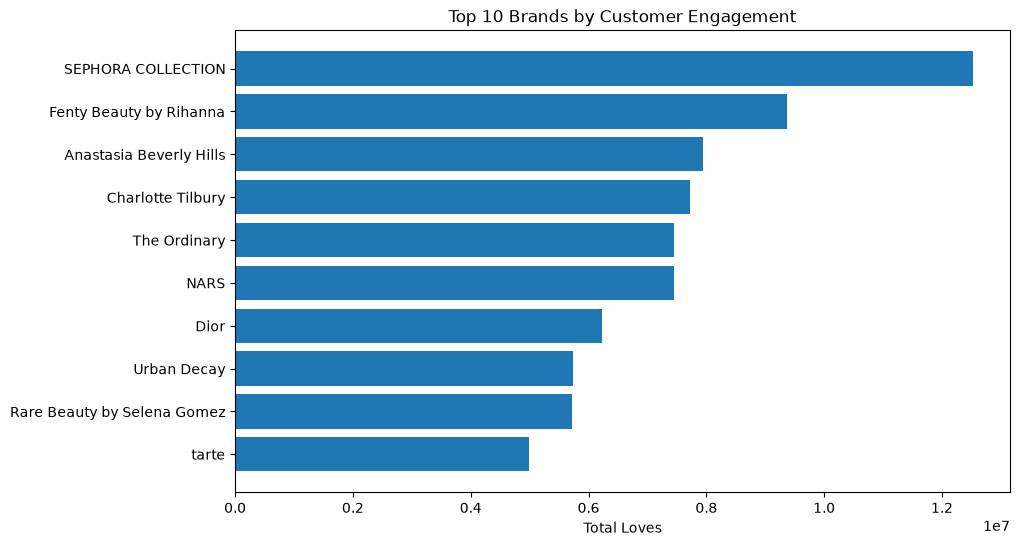

In [15]:
import matplotlib.pyplot as plt

top_brands = brand_summary.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_brands.index, top_brands["total_loves"])
plt.title("Top 10 Brands by Customer Engagement")
plt.xlabel("Total Loves")
plt.gca().invert_yaxis()
plt.show()

## Key Findings

• Sephora Collection dominates customer engagement due to its broad product portfolio.

• Premium brands such as Dior and Charlotte Tilbury maintain strong engagement despite having fewer products.

• High engagement is not limited to luxury brands, suggesting that affordability and product variety also contribute to popularity.

## Business Recommendation

Brands with consistently high engagement could receive greater homepage visibility, promotional campaigns or exclusive launches to maximize customer interaction.

## Category Analysis

In [16]:
category_summary = (
    products
    .groupby("primary_category")
    .agg(
        products=("product_id","count"),
        avg_rating=("rating","mean"),
        total_loves=("loves_count","sum"),
        avg_price=("price_usd","mean")
    )
)

category_summary

,products,avg_rating,total_loves,avg_price
primary_category,,,,
Bath & Body,405,4.195015,6663744,42.233333
Fragrance,1432,4.230889,18269036,87.262570
Gifts,4,4.563450,0,50.000000
Hair,1464,4.201113,20071798,42.786701
Makeup,2368,4.146585,128447594,32.742690
Men,60,4.504992,291352,33.200000
Mini Size,288,4.005665,7682967,21.397569
Skincare,2420,4.228890,65609028,60.512500
Tools & Brushes,52,4.271458,779422,31.922115


In [17]:
category_summary.sort_values(
    "avg_rating",
    ascending=False
)

,products,avg_rating,total_loves,avg_price
primary_category,,,,
Gifts,4,4.563450,0,50.000000
Men,60,4.504992,291352,33.200000
Tools & Brushes,52,4.271458,779422,31.922115
Fragrance,1432,4.230889,18269036,87.262570
Skincare,2420,4.228890,65609028,60.512500
Hair,1464,4.201113,20071798,42.786701
Bath & Body,405,4.195015,6663744,42.233333
Makeup,2368,4.146585,128447594,32.742690
Mini Size,288,4.005665,7682967,21.397569


In [18]:
category_summary.sort_values(
    "total_loves",
    ascending=False
)

,products,avg_rating,total_loves,avg_price
primary_category,,,,
Makeup,2368,4.146585,128447594,32.742690
Skincare,2420,4.228890,65609028,60.512500
Hair,1464,4.201113,20071798,42.786701
Fragrance,1432,4.230889,18269036,87.262570
Mini Size,288,4.005665,7682967,21.397569
Bath & Body,405,4.195015,6663744,42.233333
Tools & Brushes,52,4.271458,779422,31.922115
Men,60,4.504992,291352,33.200000
Gifts,4,4.563450,0,50.000000


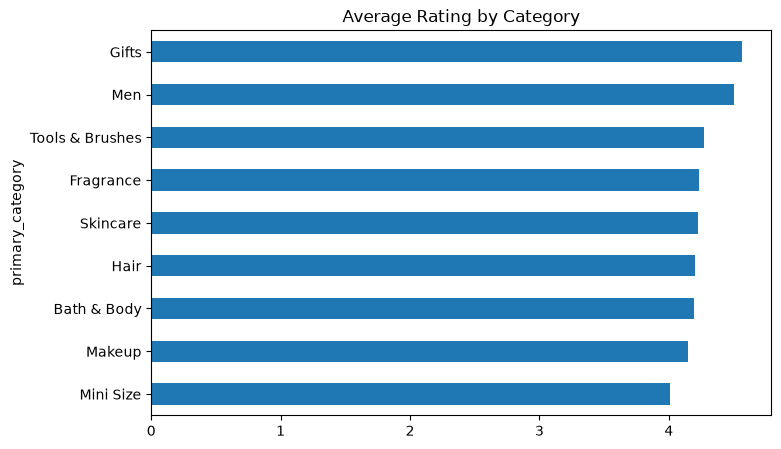

In [19]:
category_summary["avg_rating"].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Average Rating by Category")
plt.show()

## Key Findings

• Skincare and Makeup concentrate most of the catalog.

• Customer satisfaction is consistently high across categories.

• Smaller categories represent niche opportunities.

## Business Recommendation

Investments should prioritize high-performing categories while exploring growth opportunities within smaller segments.

## Pricing Analysis

In [20]:
price_summary = (
    products
    .groupby("price_segment")
    .agg(
        avg_rating=("rating","mean"),
        avg_price=("price_usd","mean"),
        total_loves=("loves_count","sum"),
        products=("product_id","count")
    )
)

price_summary

,avg_rating,avg_price,total_loves,products
price_segment,,,,
Budget,4.020819,13.933461,39752398,1205
Luxury,4.269806,166.838722,13485916,931
Mid-range,4.203493,32.341543,160162981,4724
Premium,4.255040,69.684936,34413646,1633


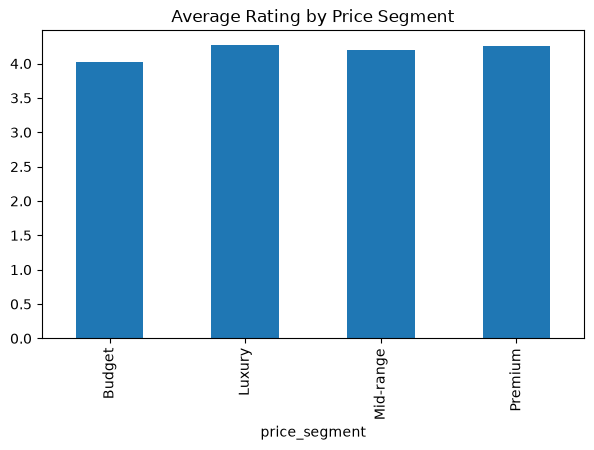

In [21]:
price_summary["avg_rating"].plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Average Rating by Price Segment")
plt.show()

## Key Findings

• Mid-range products dominate the marketplace.

• Luxury products represent a smaller portion of the catalog.

• Higher prices do not necessarily translate into higher customer ratings.

## Business Recommendation

Maintaining a strong mid-range assortment appears to maximize customer reach while preserving satisfaction.

## Business Opportunities

In [22]:
products.sort_values(
    "rating",
    ascending=False
)[[
    "product_name",
    "brand_name",
    "rating",
    "reviews"
]].head(15)

,product_name,brand_name,rating,reviews
8487,Libre Eau de Parfum Gift Set,Yves Saint Laurent,5.0,1.0
8482,L'Homme Le Parfum,Yves Saint Laurent,5.0,6.0
7832,Ebene Fume Eau de Parfum Travel Spray,TOM FORD,5.0,2.0
7826,Fougère d'Argent,TOM FORD,5.0,9.0
7816,Rose Prick Candle,TOM FORD,5.0,2.0
7802,Lost Cherry Perfume Set,TOM FORD,5.0,3.0
747,Anti-Frizz Hair Mask,BondiBoost,5.0,13.0
7740,Florence Travel Spray,TOCCA,5.0,5.0
4810,E 3 Makeup Brush,MAKEUP BY MARIO,5.0,5.0
4420,Mini Advanced Génifique Radiance Boosting Face...,Lancôme,5.0,1.0


In [23]:
products.sort_values(
    "out_of_stock",
    ascending=False
)[[
    "product_name",
    "brand_name",
    "out_of_stock"
]].head(20)

,product_name,brand_name,out_of_stock
3538,The Healthy Skin Edit Bestsellers Kit,iNNBEAUTY PROJECT,1
1462,Beyond Perfecting Super Concealer Camouflage +...,CLINIQUE,1
1463,Clinique iD Custom-Blend Hydrator Collection,CLINIQUE,1
8477,Mon Paris Couture Eau de Parfum,Yves Saint Laurent,1
499,BOUNCE Airbrush Liquid Whip Concealer,beautyblender,1
3316,Equilibrium The Essentials Set,Hourglass,1
1924,Rouge Dior Ultra Care Liquid Lipstick,Dior,1
1925,Miss Dior Blooming Bouquet Roller-pearl,Dior,1
2617,Fenty Skin Travel Size Start'r Set,Fenty Skin,1
3571,Self-Tanning Water Refill,Isle of Paradise,1


In [24]:
category_summary = (
    products
    .groupby("primary_category")
    .agg(
        products=("product_id","count"),
        avg_rating=("rating","mean"),
        total_loves=("loves_count","sum"),
        avg_price=("price_usd","mean")
    )
    .round(2)
)

category_summary

,products,avg_rating,total_loves,avg_price
primary_category,,,,
Bath & Body,405,4.20,6663744,42.23
Fragrance,1432,4.23,18269036,87.26
Gifts,4,4.56,0,50.00
Hair,1464,4.20,20071798,42.79
Makeup,2368,4.15,128447594,32.74
Men,60,4.50,291352,33.20
Mini Size,288,4.01,7682967,21.40
Skincare,2420,4.23,65609028,60.51
Tools & Brushes,52,4.27,779422,31.92


In [25]:
category_summary.to_csv(
    "../data/category_summary.csv",
    index=True
)

## Business Opportunities

• Highly rated products with limited visibility could benefit from additional promotion.

• Frequently out-of-stock brands may indicate strong demand or inventory constraints.

• Mid-range products continue to offer the strongest balance between affordability and customer engagement.

# Business Insights

Based on the exploratory analysis, several business opportunities were identified.

## Key findings

- Makeup concentrates the largest share of the catalog and customer engagement.
- Skincare products maintain one of the highest average ratings across all categories.
- Mid-range products generate the highest engagement while maintaining competitive ratings.
- Premium and Luxury products achieve higher average ratings but represent a smaller portion of total engagement.
- Several products present excellent ratings with very few reviews, representing potential opportunities for additional visibility and marketing support.
- Out-of-stock products are concentrated in a limited number of brands, suggesting possible inventory optimization opportunities.

## Recommendations

- Increase visibility for highly-rated products with low review volume.
- Prioritize inventory planning for brands with frequent stock shortages.
- Continue investing in high-performing mid-range products that balance affordability and customer satisfaction.
- Monitor customer engagement metrics alongside product ratings to identify future growth opportunities.